# 02 — Análisis de la serie total (S0)

**Serie:** `S0_total` · **Unidad:** viajeros por mes ·
**Filtro:** Turista + Excursionista

## Resumen técnico

S0 presenta crecimiento y estacionalidad antes de 2020, seguido de una ruptura por la pandemia. El nivel no supera ADF al 5%; la primera diferencia del logaritmo sí lo hace.

El análisis de estacionariedad y la descomposición se realizan exclusivamente
sobre entrenamiento (enero de 2009 a marzo de 2021). El tramo de prueba se
conserva intacto para la evaluación predictiva de la entrega final.

## 1. Contexto y metodología

La serie se agrega al inicio de cada mes (`MS`) y usa una frecuencia estacional
de 12 observaciones por año. La partición es temporal: los primeros 147 meses
forman entrenamiento y los últimos 63 forman prueba. No se barajan los datos.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

RAIZ = Path.cwd().resolve()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

import config
from utils_ts import (
    cargar_serie,
    descomponer,
    fuerza_estacional,
    fuerza_tendencia,
    partir_train_test,
    test_estacionariedad,
)

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12})

DIR_IMG = RAIZ / "informe" / "img"
DIR_IMG.mkdir(parents=True, exist_ok=True)

serie = cargar_serie("S0_total")
train, test = partir_train_test(serie)

resumen = pd.DataFrame({
    "serie": ["S0 — Total mensual"],
    "inicio_total": [serie.index.min().strftime("%Y-%m")],
    "fin_total": [serie.index.max().strftime("%Y-%m")],
    "frecuencia": ["mensual (m=12)"],
    "meses_total": [len(serie)],
    "inicio_train": [train.index.min().strftime("%Y-%m")],
    "fin_train": [train.index.max().strftime("%Y-%m")],
    "meses_train": [len(train)],
    "inicio_test": [test.index.min().strftime("%Y-%m")],
    "fin_test": [test.index.max().strftime("%Y-%m")],
    "meses_test": [len(test)],
})
resumen

,serie,inicio_total,fin_total,frecuencia,meses_total,inicio_train,fin_train,meses_train,inicio_test,fin_test,meses_test
0,S0 — Total mensual,2009-01,2026-06,mensual (m=12),210,2009-01,2021-03,147,2021-04,2026-06,63


## 2. La serie completa muestra el corte pandémico y la recuperación

La gráfica presenta todo el período para dar contexto, pero el análisis
estadístico posterior solo utiliza el tramo anterior a la línea de corte.

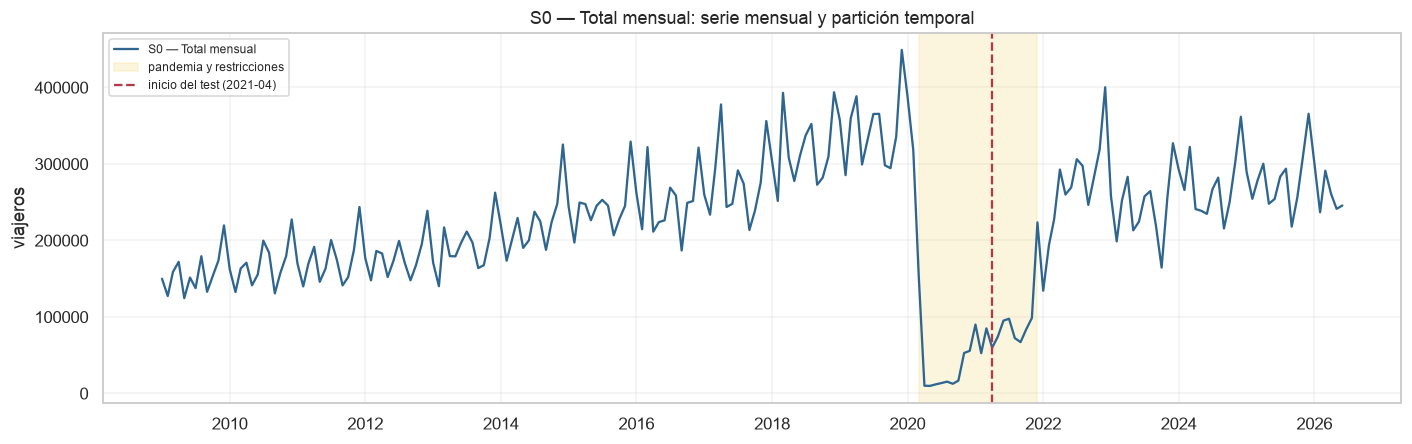

Mínimo de entrenamiento: 9,779 viajeros (2020-05)
Máximo de entrenamiento: 449,114 viajeros (2019-12)


In [2]:
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(serie.index, serie.values, color="#2f6690", linewidth=1.5,
        label="S0 — Total mensual")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
           color="#f2cf5b", alpha=0.20, label="pandemia y restricciones")
ax.axvline(test.index.min(), color="#b23a48", linestyle="--", linewidth=1.5,
           label="inicio del test (2021-04)")
ax.set_title("S0 — Total mensual: serie mensual y partición temporal")
ax.set_ylabel("viajeros")
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(DIR_IMG / "2_s0_serie.png", bbox_inches="tight")
plt.show()

print(f"Mínimo de entrenamiento: {train.min():,.0f} viajeros "
      f"({train.idxmin():%Y-%m})")
print(f"Máximo de entrenamiento: {train.max():,.0f} viajeros "
      f"({train.idxmax():%Y-%m})")

A primera vista se distingue un crecimiento sostenido entre 2009 y 2019, oscilaciones anuales y un máximo en diciembre de 2019. En marzo de 2020 comienza el colapso por la pandemia. El corte de entrenamiento ocurre en marzo de 2021, cuando la recuperación todavía era incompleta; por ello el futuro test contiene un régimen distinto al tramo final del entrenamiento.

## 3. La descomposición confirma tendencia y estacionalidad

Se utiliza una descomposición aditiva con período 12. La pandemia rompe
temporalmente el patrón y debe interpretarse como un cambio estructural, no
como un error de captura.

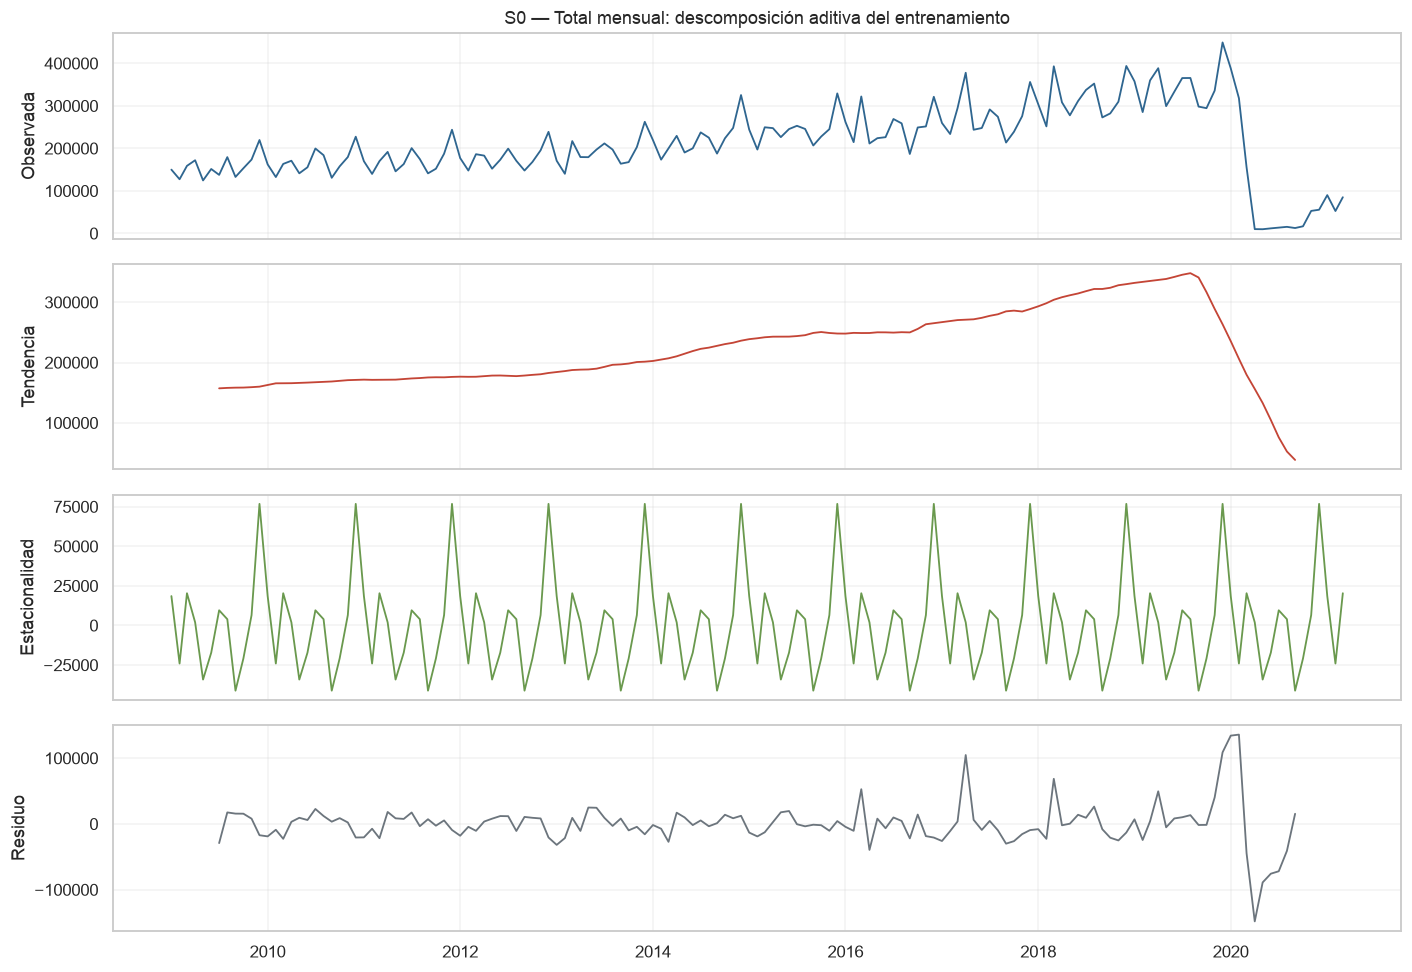

Fuerza estacional: 0.467
Fuerza de tendencia: 0.821


In [3]:
descomp = descomponer(train, modelo="additive", graficar=False)

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
componentes = [
    (train, "Observada", "#2f6690"),
    (descomp.trend, "Tendencia", "#c44536"),
    (descomp.seasonal, "Estacionalidad", "#6a994e"),
    (descomp.resid, "Residuo", "#6c757d"),
]
for ax, (datos, nombre, color) in zip(axes, componentes):
    ax.plot(datos.index, datos.values, color=color, linewidth=1.2)
    ax.set_ylabel(nombre)
    ax.grid(alpha=0.25)
axes[0].set_title("S0 — Total mensual: descomposición aditiva del entrenamiento")
fig.tight_layout()
fig.savefig(DIR_IMG / "2_s0_descomposicion.png", bbox_inches="tight")
plt.show()

print(f"Fuerza estacional: {fuerza_estacional(descomp):.3f}")
print(f"Fuerza de tendencia: {fuerza_tendencia(descomp):.3f}")

La tendencia cambia a lo largo del tiempo y la componente estacional repite un patrón mensual, por lo que la media no es constante. La dispersión de los residuos aumenta durante el choque pandémico. La serie no puede considerarse estacionaria en media y la varianza debe analizarse en una escala relativa.

## 4. La transformación logarítmica es adecuada para la varianza

Como la serie es estrictamente positiva, el logaritmo es aplicable. Se compara
la media y desviación móvil de 12 meses antes y después de transformar.

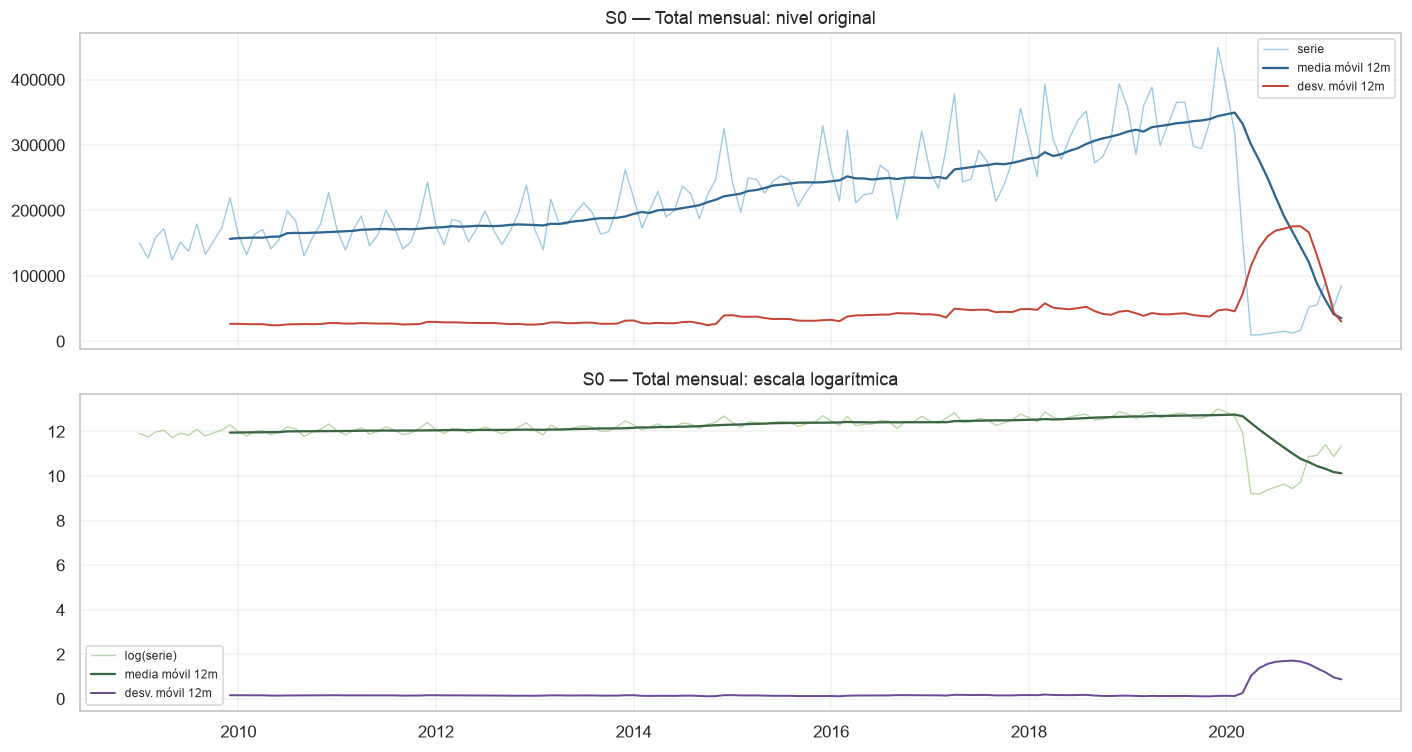

Correlación media-desviación móvil, nivel: 0.037
Correlación media-desviación móvil, log: -0.695


In [4]:
log_train = np.log(train)
media_movil = train.rolling(12).mean()
desv_movil = train.rolling(12).std()
media_log = log_train.rolling(12).mean()
desv_log = log_train.rolling(12).std()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(train.index, train, color="#9ecae1", linewidth=0.9,
             label="serie")
axes[0].plot(media_movil.index, media_movil, color="#2f6690",
             linewidth=1.5, label="media móvil 12m")
axes[0].plot(desv_movil.index, desv_movil, color="#c44536",
             linewidth=1.3, label="desv. móvil 12m")
axes[0].set_title("S0 — Total mensual: nivel original")
axes[0].legend(fontsize=8)

axes[1].plot(log_train.index, log_train, color="#b7d7a8", linewidth=0.9,
             label="log(serie)")
axes[1].plot(media_log.index, media_log, color="#386641",
             linewidth=1.5, label="media móvil 12m")
axes[1].plot(desv_log.index, desv_log, color="#6a4c93",
             linewidth=1.3, label="desv. móvil 12m")
axes[1].set_title("S0 — Total mensual: escala logarítmica")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(DIR_IMG / "2_s0_varianza.png", bbox_inches="tight")
plt.show()

print(f"Correlación media-desviación móvil, nivel: "
      f"{media_movil.corr(desv_movil):.3f}")
print(f"Correlación media-desviación móvil, log: "
      f"{media_log.corr(desv_log):.3f}")

Se adopta `log(S0)` porque todos los valores son positivos y la transformación expresa los cambios de forma relativa, reduce la influencia de los picos y hace más comparable la amplitud estacional entre niveles. El logaritmo no elimina la ruptura de 2020, que seguirá tratándose como limitación estructural del entrenamiento.

## 5. ACF y pruebas formales: se requiere diferenciación

ADF usa como hipótesis nula la presencia de raíz unitaria; KPSS usa como
hipótesis nula la estacionariedad. Se revisan nivel, logaritmo, primera
diferencia, diferencia estacional y la combinación de ambas.

In [5]:
transformaciones = {
    "Nivel": train,
    "Log": log_train,
    "Δ Log (d=1)": log_train.diff().dropna(),
    "Δ12 Log (D=1)": log_train.diff(12).dropna(),
    "Δ Δ12 Log (d=1, D=1)": log_train.diff().diff(12).dropna(),
}

resultados = []
for nombre, datos in transformaciones.items():
    resultado = test_estacionariedad(datos, nombre=nombre, verbose=False)
    resultados.append({
        "transformación": nombre,
        "ADF": resultado["adf_estadistico"],
        "p ADF": resultado["adf_p"],
        "rezagos ADF": resultado["adf_rezagos"],
        "KPSS": resultado["kpss_estadistico"],
        "p KPSS": resultado["kpss_p"],
        "veredicto": resultado["veredicto"],
    })

tabla_pruebas = pd.DataFrame(resultados)
tabla_pruebas.round({
    "ADF": 4, "p ADF": 4, "KPSS": 4, "p KPSS": 4
})

,transformación,ADF,p ADF,rezagos ADF,KPSS,p KPSS,veredicto
0,Nivel,-2.3644,0.1520,13,0.4019,0.0763,"resultado mixto: KPSS dice estacionaria, ADF no"
1,Log,-2.4993,0.1156,12,0.1750,0.1000,"resultado mixto: KPSS dice estacionaria, ADF no"
2,Δ Log (d=1),-3.0853,0.0277,11,0.0509,0.1000,estacionaria (ambas pruebas coinciden)
3,Δ12 Log (D=1),0.0657,0.9636,12,0.5544,0.0294,NO estacionaria (ambas pruebas coinciden)
4,"Δ Δ12 Log (d=1, D=1)",-6.5386,0.0000,11,0.0372,0.1000,estacionaria (ambas pruebas coinciden)


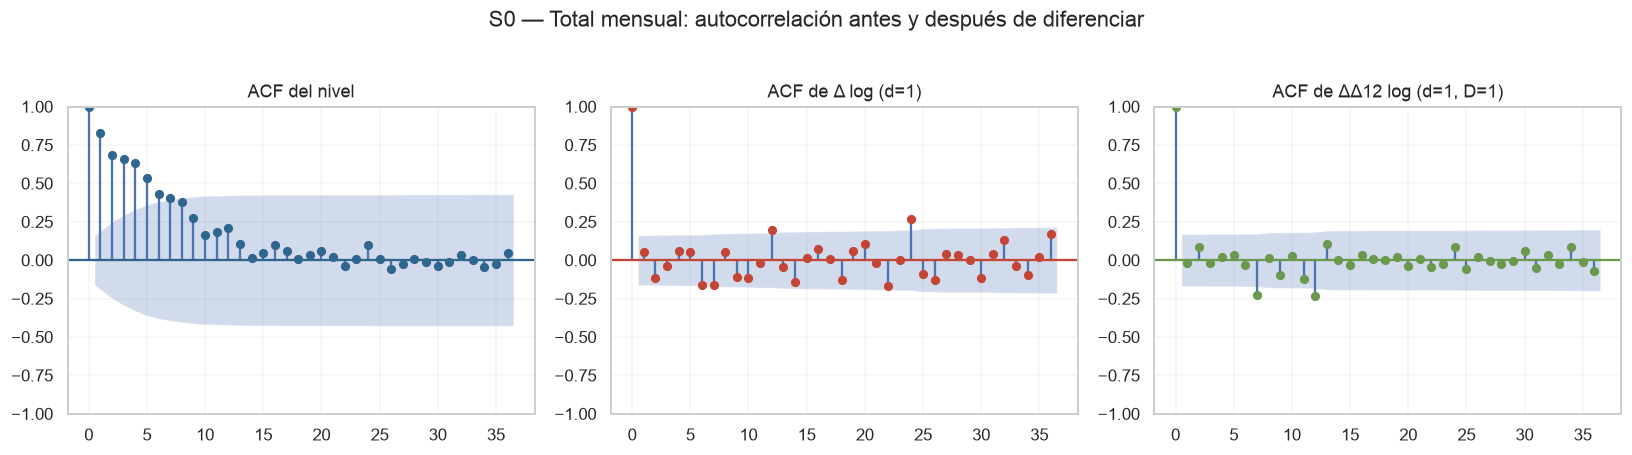

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_acf(train, lags=36, ax=axes[0], color="#2f6690")
axes[0].set_title("ACF del nivel")
plot_acf(log_train.diff().dropna(), lags=36, ax=axes[1], color="#c44536")
axes[1].set_title("ACF de Δ log (d=1)")
plot_acf(log_train.diff().diff(12).dropna(), lags=36,
         ax=axes[2], color="#6a994e")
axes[2].set_title("ACF de ΔΔ12 log (d=1, D=1)")
for ax in axes:
    ax.grid(alpha=0.20)
fig.suptitle("S0 — Total mensual: autocorrelación antes y después de diferenciar",
             y=1.03)
fig.tight_layout()
fig.savefig(DIR_IMG / "2_s0_acf.png", bbox_inches="tight")
plt.show()

En nivel, ADF no rechaza la raíz unitaria (`p≈0.152`) y la ACF decae lentamente, coherente con no estacionariedad en media. En el logaritmo el resultado sigue sin ser suficiente (`p≈0.116`). La primera diferencia del logaritmo sí rechaza la raíz unitaria (`p≈0.028`) y KPSS no rechaza estacionariedad, por lo que se propone `d=1`. Los picos estacionales justifican evaluar además `D=1`; la combinación `d=1, D=1` supera ambas pruebas con holgura.

## 6. Conclusión para el avance

| Serie | Inicio–fin | Frecuencia | ¿Estacionaria en nivel? | Transformación | `d` propuesto | `D` estacional candidato |
|---|---|---|---|---|---:|---:|
| S0 — Total mensual | ene 2009–jun 2026 | mensual (`m=12`) | No | log | 1 | 1 |

Para la siguiente fase se trabajará con la escala logarítmica y una diferencia regular. La diferencia estacional se comparará como candidata en los modelos SARIMA, sin utilizar el conjunto de prueba para escogerla.

La selección de `p`, `q` y de los modelos predictivos se deja para la entrega
final, tal como establece la planificación del avance.